# 第301章: VAE潜在空間の探索

## 📋 この章で学ぶこと

この章を終えると、以下ができるようになります：

- [ ] 訓練済みVAEの潜在空間をt-SNE/PCAで可視化し、クラスタ構造を分析できる
- [ ] 高次元（10-64次元）の潜在空間をt-SNEで2Dに射影して観察できる
- [ ] 潜在空間の任意の点からデコーダで画像を復元し、空間の「密度」を理解できる
- [ ] クラスタ間の境界・重なりを分析し、潜在表現の質を評価できる
- [ ] 潜在次元数が表現力と可視化に与える影響を実験的に理解できる

## 🎯 前提知識

この章を学ぶには以下の知識が必要です：

- ✅ Notebook 300（潜在空間とは何か）
- ✅ Notebook 37-38（VAE理論と実装）
- ✅ PCA/t-SNEの基本概念（Notebook 154推奨）

⏱️ **推定学習時間**: 90-120分
📊 **難易度**: ★★★☆☆（中級）
🎓 **カテゴリ**: 基礎・分析

---

## 🌟 はじめに

前章（300）では、潜在空間の基本概念を学び、2次元の潜在空間を可視化しました。
しかし、実用的なVAEでは潜在次元は**10〜512次元**と高次元です。

この章では、高次元の潜在空間を**探索・分析するテクニック**を身につけます。

### 📝 この章の構成

1. **準備**: VAEの構築と学習（潜在次元=2, 10, 64で比較）
2. **PCAによる潜在空間分析** — 分散の方向を発見
3. **t-SNEによる可視化** — 高次元を2Dに非線形射影
4. **クラスタ構造の分析** — 数字間の境界と重なり
5. **デコーダによる探索** — 潜在空間の任意の点から画像を復元
6. **潜在次元数の影響** — 次元数と再構成品質の関係

In [1]:
# ============================================================
# 環境設定
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings

warnings.filterwarnings('ignore')

# 日本語フォント設定
def setup_japanese_font():
    japanese_fonts = [
        'Hiragino Sans', 'Hiragino Maru Gothic Pro',
        'Yu Gothic', 'MS Gothic',
        'Noto Sans CJK JP', 'IPAexGothic',
    ]
    available_fonts = set(f.name for f in fm.fontManager.ttflist)
    for font in japanese_fonts:
        if font in available_fonts:
            plt.rcParams['font.family'] = font
            plt.rcParams['axes.unicode_minus'] = False
            return font
    return None

font_used = setup_japanese_font()

device = torch.device('cuda' if torch.cuda.is_available()
                      else 'mps' if torch.backends.mps.is_available()
                      else 'cpu')

torch.manual_seed(42)
np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 8)

print(f"日本語フォント: {font_used}")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")
print("✅ ライブラリのインポート完了")

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.1.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
C:\Users\yuzup\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


日本語フォント: Yu Gothic
PyTorch: 2.1.2+cpu
Device: cpu
✅ ライブラリのインポート完了


---

## 1. 準備: 複数の潜在次元でVAEを学習する

潜在次元が変わると、潜在空間の構造はどう変わるでしょうか？
**2次元、10次元、64次元** の3つのVAEを学習して比較します。

```
  潜在次元=2    潜在次元=10     潜在次元=64
  ┌──┐          ┌──────┐       ┌──────────────────┐
  │  │  ← 直接  │      │ ←    │                  │ ←
  │  │   可視化  │  10  │ t-SNE│       64         │ t-SNE
  └──┘   可能    └──────┘ 必要  └──────────────────┘ 必要
  
  再構成: △     再構成: ○      再構成: ◎
```

In [2]:
# ============================================================
# VAEモデル（潜在次元を可変にしたバージョン）
# ============================================================

class VAE(nn.Module):
    """潜在次元を指定できるVAE"""

    def __init__(self, latent_dim=2):
        super().__init__()
        self.latent_dim = latent_dim

        # エンコーダ
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

        # デコーダ
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

print("✅ VAEクラス定義完了")

✅ VAEクラス定義完了


In [3]:
# ============================================================
# データの準備
# ============================================================

transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

print(f"✅ MNIST準備完了: 訓練{len(train_dataset)}枚, テスト{len(test_dataset)}枚")

✅ MNIST準備完了: 訓練60000枚, テスト10000枚


In [4]:
# ============================================================
# 3つの潜在次元でVAEを学習
# ============================================================

def vae_loss(x_recon, x, mu, logvar):
    recon = nn.functional.binary_cross_entropy(x_recon, x, reduction='sum')
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + kl

def train_vae(latent_dim, n_epochs=2):
    """指定した潜在次元でVAEを学習"""
    model = VAE(latent_dim=latent_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    losses = []
    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0
        for batch_x, _ in train_loader:
            batch_x = batch_x.view(-1, 784).to(device)
            x_recon, mu, logvar = model(batch_x)
            loss = vae_loss(x_recon, batch_x, mu, logvar)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_dataset)
        losses.append(avg_loss)

        if (epoch + 1) % 5 == 0:
            print(f"    Epoch {epoch+1:2d}/{n_epochs} | Loss: {avg_loss:.2f}")

    return model, losses

# 3つの潜在次元で学習
latent_dims = [2, 10, 64]
models = {}
all_losses = {}

for dim in latent_dims:
    print(f"\n{'='*50}")
    print(f"  潜在次元 = {dim} で学習開始")
    print(f"{'='*50}")
    models[dim], all_losses[dim] = train_vae(dim, n_epochs=2)

print("\n✅ 3つのVAEの学習が完了しました！")


  潜在次元 = 2 で学習開始

  潜在次元 = 10 で学習開始

  潜在次元 = 64 で学習開始

✅ 3つのVAEの学習が完了しました！


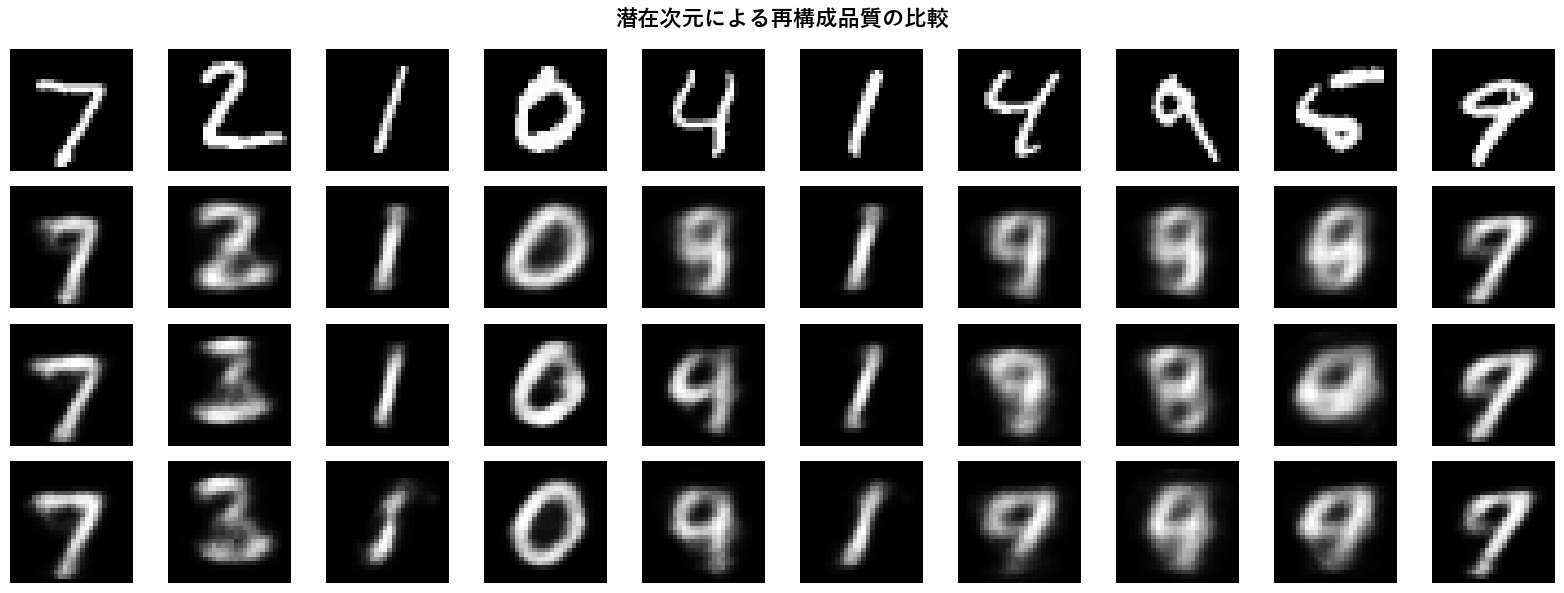

💡 観察ポイント:
   z=2:  ぼやけている  → 情報が足りない
   z=10: かなり良い    → 必要な情報を十分に保持
   z=64: ほぼ完璧     → 余剰な容量もあるが高品質


In [5]:
# ============================================================
# 潜在次元ごとの再構成品質を比較
# ============================================================

# テストデータから10枚を取得
test_images, test_labels = next(iter(test_loader))
sample_images = test_images[:10].view(-1, 784).to(device)

fig, axes = plt.subplots(4, 10, figsize=(16, 6))

# オリジナル
for i in range(10):
    axes[0, i].imshow(sample_images[i].cpu().reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('元画像', fontsize=12, rotation=0, labelpad=55)

# 各潜在次元での再構成
for row, dim in enumerate(latent_dims):
    models[dim].eval()
    with torch.no_grad():
        recon, _, _ = models[dim](sample_images)
    for i in range(10):
        axes[row+1, i].imshow(recon[i].cpu().reshape(28, 28), cmap='gray')
        axes[row+1, i].axis('off')
        if i == 0:
            axes[row+1, i].set_ylabel(f'z={dim}', fontsize=12, rotation=0, labelpad=35)

fig.suptitle('潜在次元による再構成品質の比較', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_301_01_reconstruction_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 観察ポイント:")
print("   z=2:  ぼやけている  → 情報が足りない")
print("   z=10: かなり良い    → 必要な情報を十分に保持")
print("   z=64: ほぼ完璧     → 余剰な容量もあるが高品質")

---

## 2. PCAによる潜在空間の分析

潜在次元が10や64の場合、直接2Dにプロットできません。
そこで、まず**PCA（主成分分析）**を使って、潜在空間の構造を調べます。

### PCAで何がわかるか？

- **寄与率**: 各次元がどれだけの情報量（分散）を持つか
- **主成分の方向**: データの主な変動方向
- **有効次元数**: 実質的に意味のある次元がいくつか

In [6]:
# ============================================================
# 潜在ベクトルの抽出
# ============================================================

def extract_latent_vectors(model, data_loader):
    """テストデータの潜在ベクトルとラベルを抽出"""
    model.eval()
    all_mu = []
    all_labels = []
    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            batch_x = batch_x.view(-1, 784).to(device)
            mu, _ = model.encode(batch_x)
            all_mu.append(mu.cpu().numpy())
            all_labels.append(batch_y.numpy())
    return np.concatenate(all_mu), np.concatenate(all_labels)

# 各モデルから潜在ベクトルを抽出
latent_data = {}
for dim in latent_dims:
    z, labels = extract_latent_vectors(models[dim], test_loader)
    latent_data[dim] = {'z': z, 'labels': labels}
    print(f"潜在次元={dim}: z.shape = {z.shape}")

print("\n✅ 全モデルの潜在ベクトル抽出完了")

潜在次元=2: z.shape = (10000, 2)
潜在次元=10: z.shape = (10000, 10)
潜在次元=64: z.shape = (10000, 64)

✅ 全モデルの潜在ベクトル抽出完了


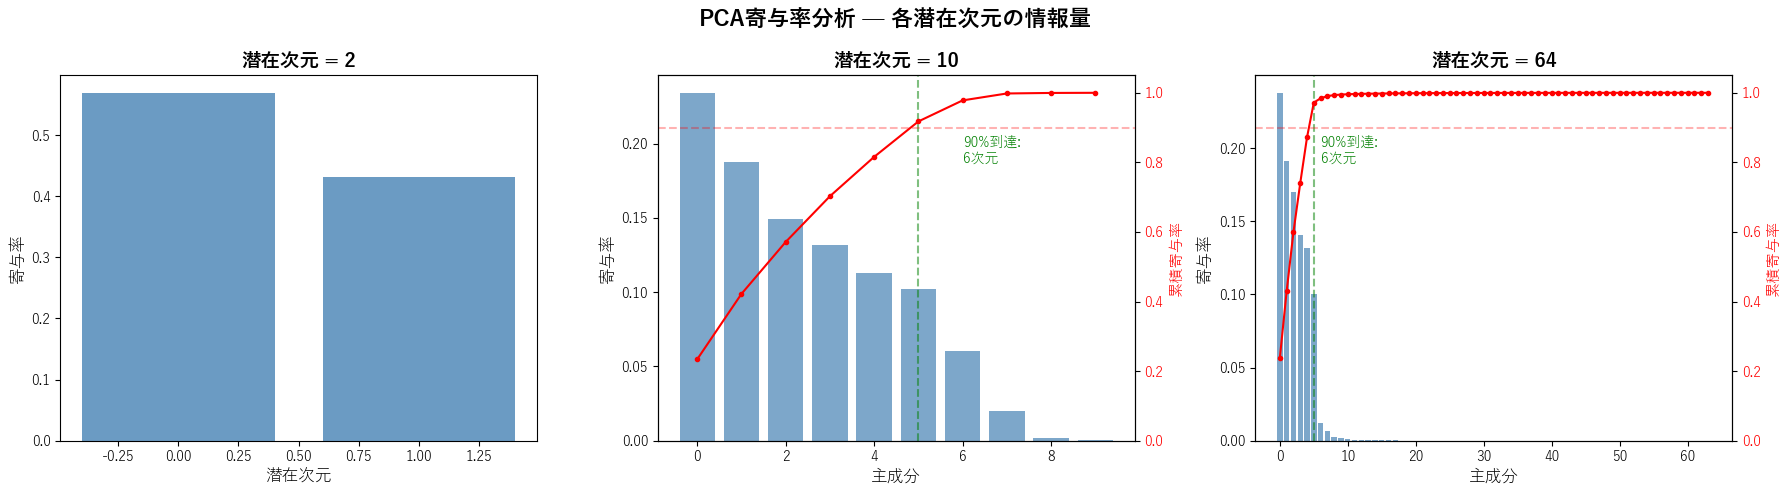

💡 観察ポイント:
   - z=10: すべての次元がそれなりの分散を持つ → 効率的な圧縮
   - z=64: 一部の次元の分散が非常に小さい → KL正則化で潰されている
   - 「有効次元数」= 実質的に使われている次元数を示す指標


In [7]:
# ============================================================
# PCA寄与率の分析
# 潜在空間の各次元がどれだけの分散を持つか
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, dim in enumerate(latent_dims):
    z = latent_data[dim]['z']

    if dim == 2:
        # 2次元の場合はそのまま分散を計算
        var_ratio = np.var(z, axis=0)
        var_ratio = var_ratio / var_ratio.sum()
        axes[idx].bar(range(dim), var_ratio, color='steelblue', alpha=0.8)
        axes[idx].set_xlabel('潜在次元', fontsize=12)
    else:
        pca = PCA(n_components=dim)
        pca.fit(z)
        var_ratio = pca.explained_variance_ratio_

        # 累積寄与率も表示
        cumulative = np.cumsum(var_ratio)
        axes[idx].bar(range(dim), var_ratio, color='steelblue', alpha=0.7, label='各次元')
        ax2 = axes[idx].twinx()
        ax2.plot(range(dim), cumulative, 'r-o', markersize=3, label='累積')
        ax2.set_ylabel('累積寄与率', fontsize=11, color='red')
        ax2.set_ylim(0, 1.05)
        ax2.axhline(y=0.9, color='red', linestyle='--', alpha=0.3)
        ax2.tick_params(axis='y', labelcolor='red')

        # 90%ラインに到達する次元数
        n_90 = np.argmax(cumulative >= 0.9) + 1
        axes[idx].axvline(x=n_90-1, color='green', linestyle='--', alpha=0.5)
        axes[idx].text(n_90, max(var_ratio)*0.8, f'90%到達:\n{n_90}次元',
                      fontsize=10, color='green')

        axes[idx].set_xlabel('主成分', fontsize=12)

    axes[idx].set_ylabel('寄与率', fontsize=12)
    axes[idx].set_title(f'潜在次元 = {dim}', fontsize=14, fontweight='bold')

fig.suptitle('PCA寄与率分析 — 各潜在次元の情報量', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_301_02_pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 観察ポイント:")
print("   - z=10: すべての次元がそれなりの分散を持つ → 効率的な圧縮")
print("   - z=64: 一部の次元の分散が非常に小さい → KL正則化で潰されている")
print("   - 「有効次元数」= 実質的に使われている次元数を示す指標")

---

## 3. t-SNEによる潜在空間の可視化

**t-SNE（t-distributed Stochastic Neighbor Embedding）** は、
高次元データの「近傍関係」を保ちながら2Dに射影する手法です。

PCAとの違い：
| 手法 | 変換 | 保存するもの | 速度 |
|------|------|-----------|------|
| PCA | 線形 | 全体の分散 | 速い |
| t-SNE | 非線形 | 近傍点間の距離 | 遅い |

潜在空間のクラスタ構造を視覚的に確認するのに最適です。

  t-SNE計算中 (z=10)... 完了
  t-SNE計算中 (z=64)... 完了


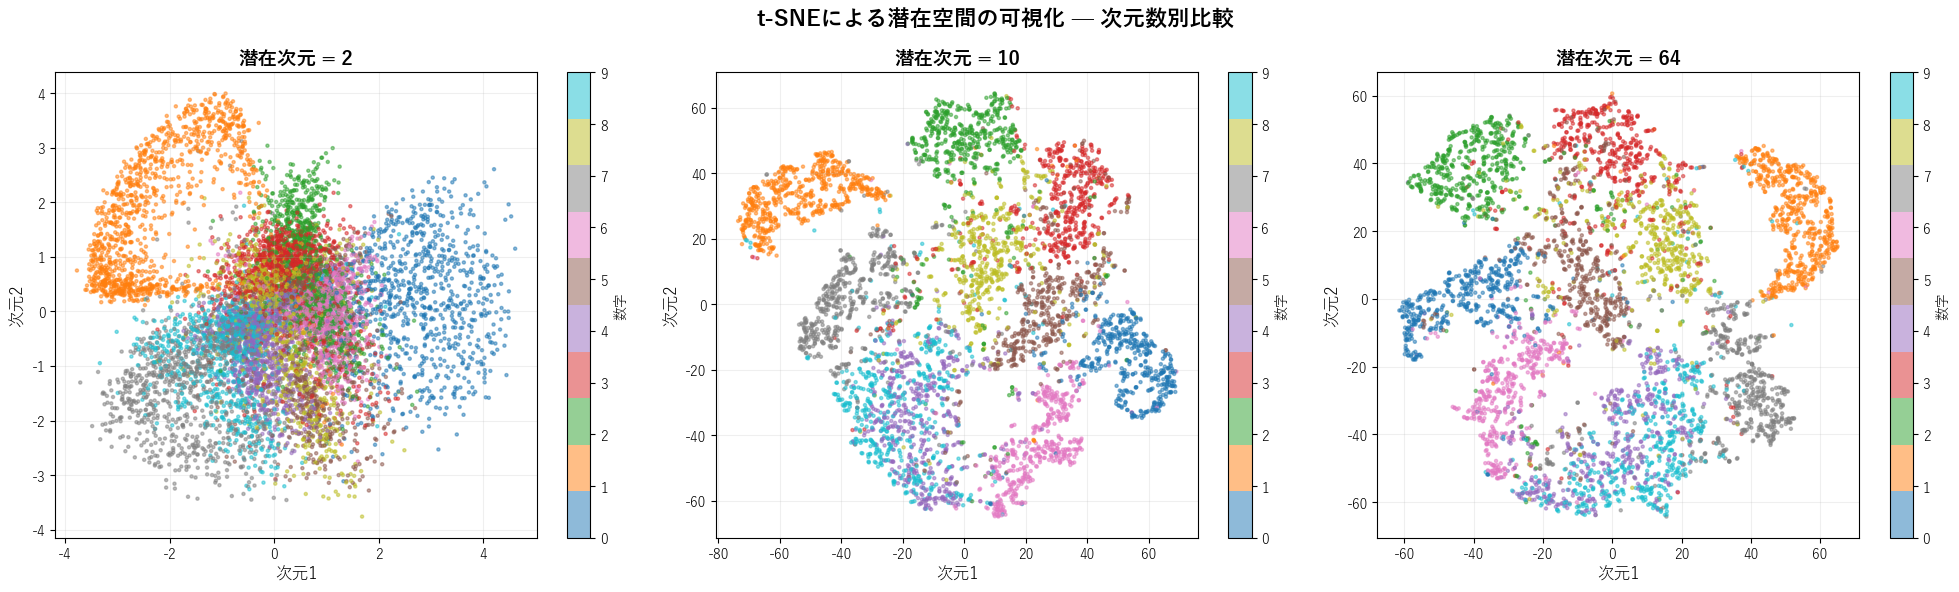


💡 観察ポイント:
   z=2:  数字のクラスタが重なっている部分が多い
   z=10: クラスタがよりはっきりと分離している
   z=64: さらに明確な分離（ただし潰れた次元もある）


In [8]:
# ============================================================
# 3つの潜在空間を t-SNE で可視化
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, dim in enumerate(latent_dims):
    z = latent_data[dim]['z']
    labels = latent_data[dim]['labels']

    if dim == 2:
        # 2次元はそのまま表示
        z_2d = z
    else:
        # t-SNEで2次元に射影（計算に少し時間がかかります）
        print(f"  t-SNE計算中 (z={dim})...", end=" ")
        tsne = TSNE(n_components=2, perplexity=30, random_state=42)
        z_2d = tsne.fit_transform(z[:5000])  # 速度のため5000点に制限
        labels = labels[:5000]
        print("完了")

    scatter = axes[idx].scatter(z_2d[:, 0], z_2d[:, 1],
                                c=labels, cmap='tab10', alpha=0.5, s=5)
    axes[idx].set_title(f'潜在次元 = {dim}', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('次元1', fontsize=12)
    axes[idx].set_ylabel('次元2', fontsize=12)
    axes[idx].grid(True, alpha=0.2)

    # カラーバー
    cbar = plt.colorbar(scatter, ax=axes[idx], ticks=range(10))
    cbar.set_label('数字')

fig.suptitle('t-SNEによる潜在空間の可視化 — 次元数別比較', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_301_03_tsne_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print("💡 観察ポイント:")
print("   z=2:  数字のクラスタが重なっている部分が多い")
print("   z=10: クラスタがよりはっきりと分離している")
print("   z=64: さらに明確な分離（ただし潰れた次元もある）")

---

## 4. クラスタ構造の詳細分析

潜在空間での数字の「近さ」は、形の類似性を反映しています。
どの数字同士が近いか分析してみましょう。

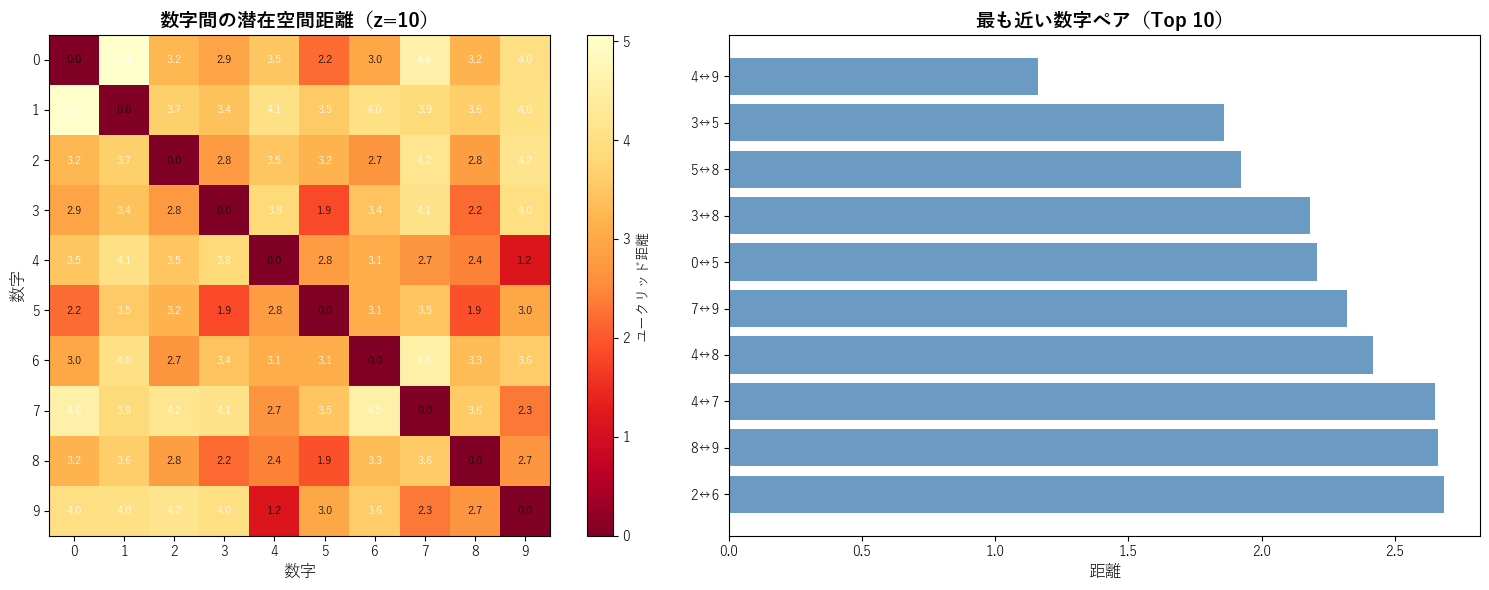

💡 形が似ている数字ほど潜在空間で近い:
   最も近いペア: (4, 9) (距離: 1.16)
   2番目: (3, 5) (距離: 1.86)
   3番目: (5, 8) (距離: 1.92)


In [9]:
# ============================================================
# 数字ごとの中心点と距離行列
# 潜在次元=10のモデルを詳しく分析
# ============================================================

z_10 = latent_data[10]['z']
labels_10 = latent_data[10]['labels']

# 各数字の中心（セントロイド）を計算
centroids = {}
for digit in range(10):
    mask = labels_10 == digit
    centroids[digit] = z_10[mask].mean(axis=0)

# 数字間のユークリッド距離行列
distance_matrix = np.zeros((10, 10))
for i in range(10):
    for j in range(10):
        distance_matrix[i, j] = np.linalg.norm(centroids[i] - centroids[j])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ヒートマップ
im = axes[0].imshow(distance_matrix, cmap='YlOrRd_r', interpolation='nearest')
axes[0].set_xticks(range(10))
axes[0].set_yticks(range(10))
axes[0].set_xlabel('数字', fontsize=12)
axes[0].set_ylabel('数字', fontsize=12)
axes[0].set_title('数字間の潜在空間距離（z=10）', fontsize=14, fontweight='bold')

# 数値をセルに表示
for i in range(10):
    for j in range(10):
        color = 'white' if distance_matrix[i, j] > distance_matrix.max() * 0.6 else 'black'
        axes[0].text(j, i, f'{distance_matrix[i, j]:.1f}',
                    ha='center', va='center', fontsize=8, color=color)

plt.colorbar(im, ax=axes[0], label='ユークリッド距離')

# 最も近い数字ペアを表示
upper = np.triu_indices(10, k=1)
distances = distance_matrix[upper]
digit_pairs = list(zip(upper[0], upper[1]))
sorted_pairs = sorted(zip(distances, digit_pairs))

axes[1].barh(range(10), [d for d, _ in sorted_pairs[:10]],
             color='steelblue', alpha=0.8)
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([f'{p[0]}↔{p[1]}' for _, p in sorted_pairs[:10]])
axes[1].set_xlabel('距離', fontsize=12)
axes[1].set_title('最も近い数字ペア（Top 10）', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('fig_301_04_cluster_distances.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 形が似ている数字ほど潜在空間で近い:")
print(f"   最も近いペア: {sorted_pairs[0][1]} (距離: {sorted_pairs[0][0]:.2f})")
print(f"   2番目: {sorted_pairs[1][1]} (距離: {sorted_pairs[1][0]:.2f})")
print(f"   3番目: {sorted_pairs[2][1]} (距離: {sorted_pairs[2][0]:.2f})")

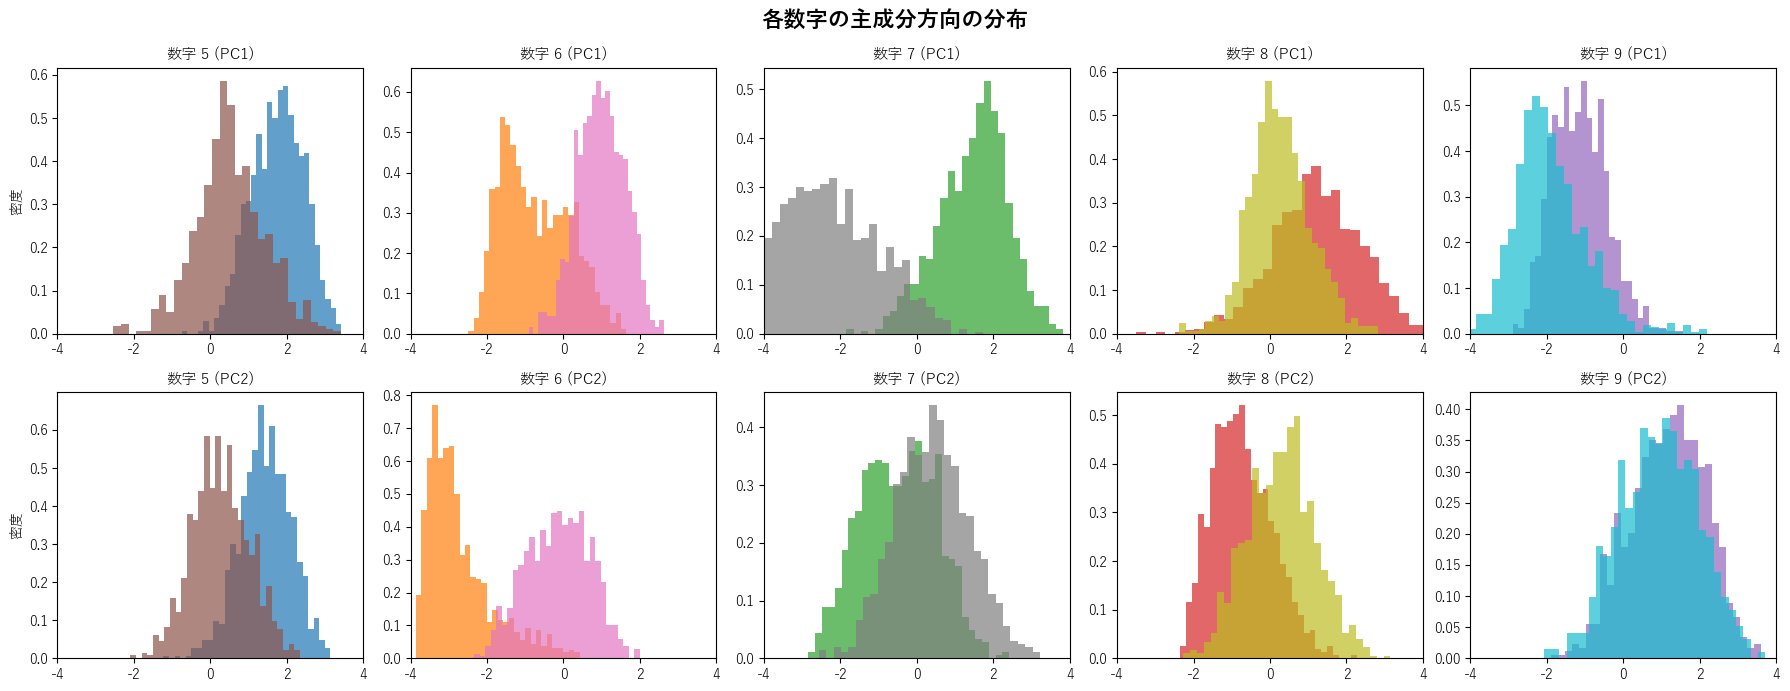

💡 分布が広い数字 = 書き方のバリエーションが多い（例: 1, 7）
   分布が狭い数字 = 書き方が安定している（例: 0）


In [10]:
# ============================================================
# クラスタの重なり分析
# 各数字の潜在ベクトルの分布を1次元で確認
# ============================================================

fig, axes = plt.subplots(2, 5, figsize=(18, 7))

# 最も分散が大きい2つの主成分方向で各数字の分布を表示
pca = PCA(n_components=2)
z_10_pca = pca.fit_transform(z_10)

colors = plt.cm.tab10(np.linspace(0, 1, 10))

for comp in range(2):
    for digit in range(10):
        ax = axes[comp, digit // 2] if digit < 10 else None
        row = comp
        col = digit % 5
        ax = axes[row, col]

        mask = labels_10 == digit
        vals = z_10_pca[mask, comp]
        ax.hist(vals, bins=30, alpha=0.7, color=colors[digit], density=True)
        ax.set_title(f'数字 {digit} (PC{comp+1})', fontsize=11)
        ax.set_xlim(-4, 4)

        if col == 0:
            ax.set_ylabel('密度', fontsize=10)

fig.suptitle('各数字の主成分方向の分布', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_301_05_cluster_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 分布が広い数字 = 書き方のバリエーションが多い（例: 1, 7）")
print("   分布が狭い数字 = 書き方が安定している（例: 0）")

---

## 5. デコーダによる潜在空間の探索

潜在空間の「地図」を作りましょう。
潜在次元=2のモデルでは、格子状に点を配置して各点からデコードすることで、
潜在空間の全体像を見ることができます。

### 🤔 密度と品質の関係

- **データが密集している領域** → 高品質な画像が生成される
- **データが少ない領域（隙間）** → ぼやけたり不自然な画像になる

これはVAEの「KL正則化」の効果を直接観察できるポイントです。

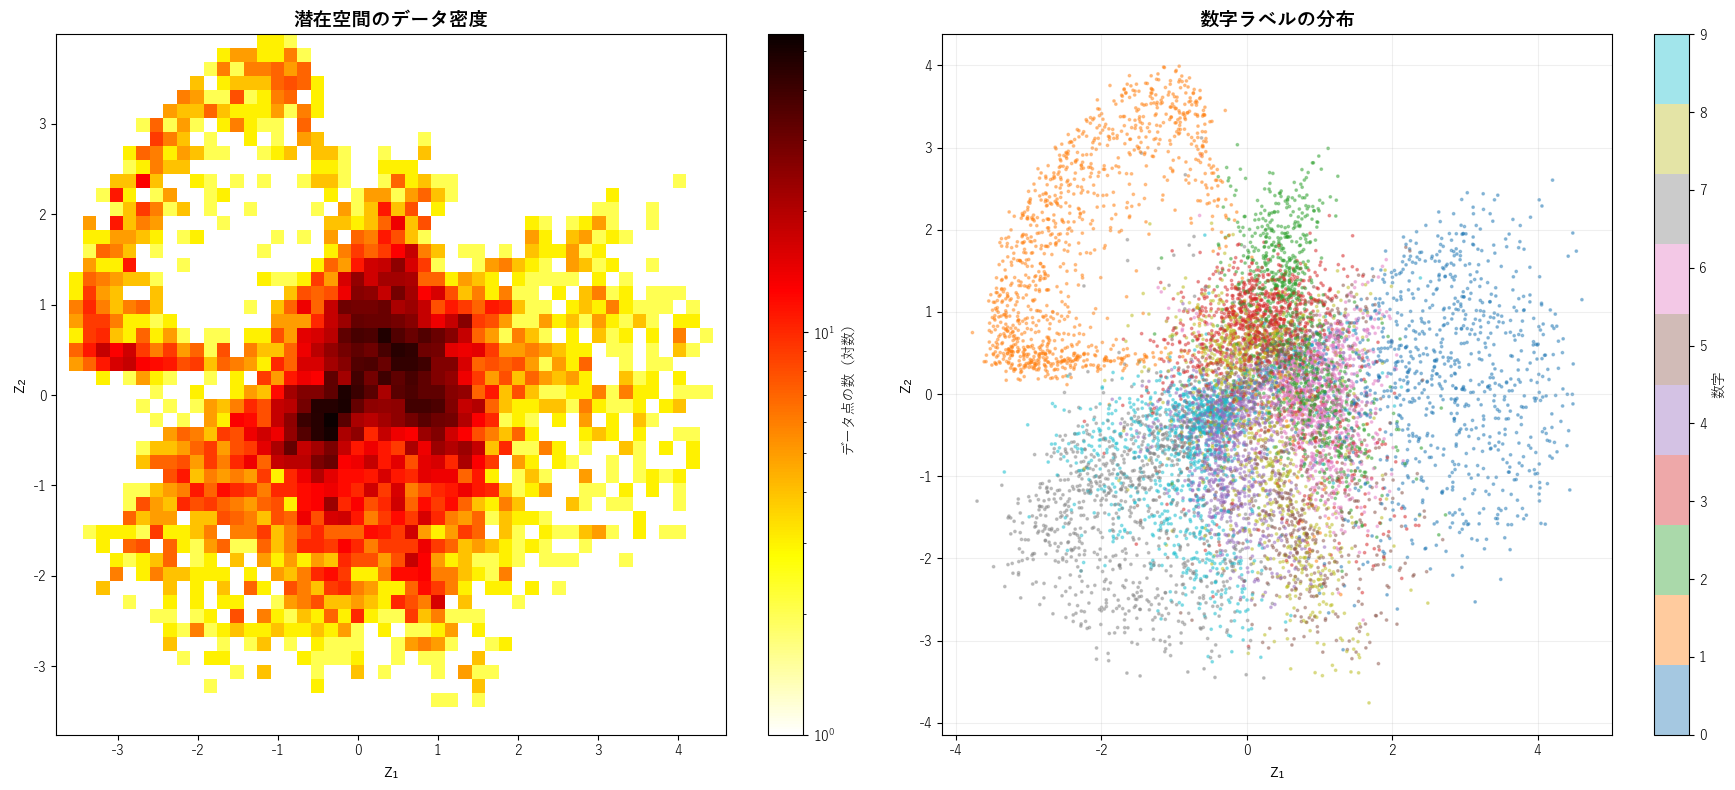

💡 密度が高い領域 = よく学習されている → 高品質な生成
   密度が低い領域 = あまり見たことがない → 品質が下がる


In [11]:
# ============================================================
# 潜在空間の「地図」— データ密度と生成品質の関係
# ============================================================

model_2d = models[2]
model_2d.eval()

z_2d = latent_data[2]['z']
labels_2d = latent_data[2]['labels']

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- 左: データ密度 ---
from matplotlib.colors import LogNorm

# 2Dヒストグラムで密度を表示
h = axes[0].hist2d(z_2d[:, 0], z_2d[:, 1], bins=50,
                   cmap='hot_r', norm=LogNorm())
axes[0].set_xlabel('z₁', fontsize=14)
axes[0].set_ylabel('z₂', fontsize=14)
axes[0].set_title('潜在空間のデータ密度', fontsize=14, fontweight='bold')
plt.colorbar(h[3], ax=axes[0], label='データ点の数（対数）')

# --- 右: クラスタ付きの散布図 ---
scatter = axes[1].scatter(z_2d[:, 0], z_2d[:, 1],
                          c=labels_2d, cmap='tab10', alpha=0.4, s=3)
axes[1].set_xlabel('z₁', fontsize=14)
axes[1].set_ylabel('z₂', fontsize=14)
axes[1].set_title('数字ラベルの分布', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.2)
plt.colorbar(scatter, ax=axes[1], ticks=range(10), label='数字')

plt.tight_layout()
plt.savefig('fig_301_06_density_map.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 密度が高い領域 = よく学習されている → 高品質な生成")
print("   密度が低い領域 = あまり見たことがない → 品質が下がる")

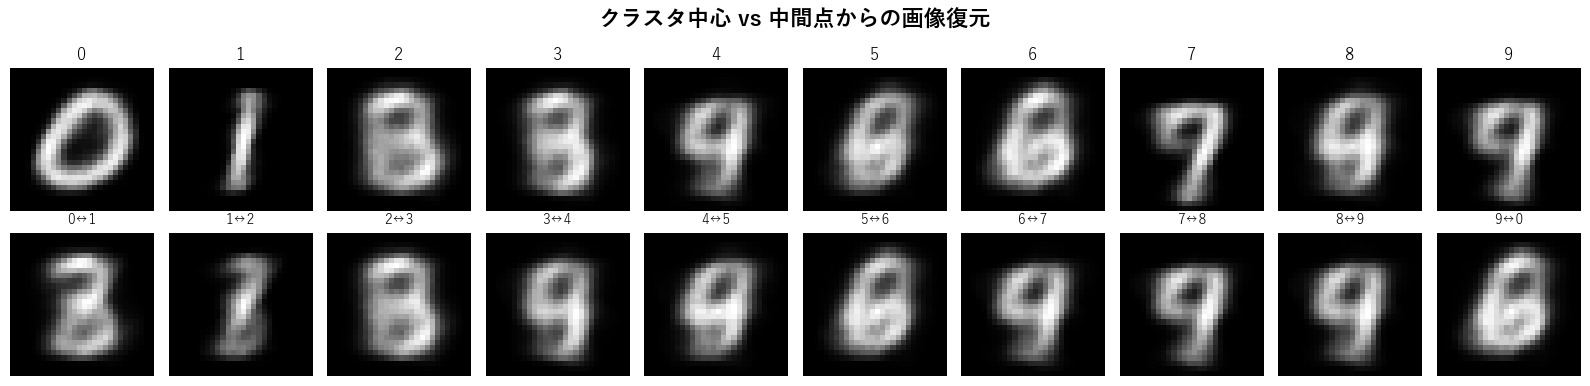

💡 上段: 各数字の「典型的な」パターン
   下段: 2つの数字の特徴が混ざった画像 → これがMorphingの原理


In [12]:
# ============================================================
# 指定した点からの画像復元
# 潜在空間の「クリック＆デコード」シミュレーション
# ============================================================

model_2d.eval()

# いくつかの興味深い点を選んでデコード
# 1) 各数字クラスタの中心
# 2) クラスタ間の中間点
# 3) 外れた位置

centroids_2d = {}
for digit in range(10):
    mask = labels_2d == digit
    centroids_2d[digit] = z_2d[mask].mean(axis=0)

# クラスタ中心からの復元
fig, axes = plt.subplots(2, 10, figsize=(16, 4))

with torch.no_grad():
    # 上段: 各数字クラスタの中心からデコード
    for digit in range(10):
        z_point = torch.tensor(centroids_2d[digit], dtype=torch.float32).unsqueeze(0).to(device)
        img = model_2d.decode(z_point).cpu().numpy().reshape(28, 28)
        axes[0, digit].imshow(img, cmap='gray')
        axes[0, digit].set_title(f'{digit}', fontsize=12)
        axes[0, digit].axis('off')
    axes[0, 0].set_ylabel('中心', fontsize=12, rotation=0, labelpad=30)

    # 下段: 隣接クラスタの中間点からデコード
    pairs = [(0,1),(1,2),(2,3),(3,4),(4,5),(5,6),(6,7),(7,8),(8,9),(9,0)]
    for i, (d1, d2) in enumerate(pairs):
        z_mid = (centroids_2d[d1] + centroids_2d[d2]) / 2
        z_point = torch.tensor(z_mid, dtype=torch.float32).unsqueeze(0).to(device)
        img = model_2d.decode(z_point).cpu().numpy().reshape(28, 28)
        axes[1, i].imshow(img, cmap='gray')
        axes[1, i].set_title(f'{d1}↔{d2}', fontsize=10)
        axes[1, i].axis('off')
    axes[1, 0].set_ylabel('中間', fontsize=12, rotation=0, labelpad=30)

fig.suptitle('クラスタ中心 vs 中間点からの画像復元', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_301_07_centroid_decode.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 上段: 各数字の「典型的な」パターン")
print("   下段: 2つの数字の特徴が混ざった画像 → これがMorphingの原理")

---

## 6. 潜在次元数の影響

最後に、潜在次元数が再構成品質にどう影響するかを定量的に確認します。

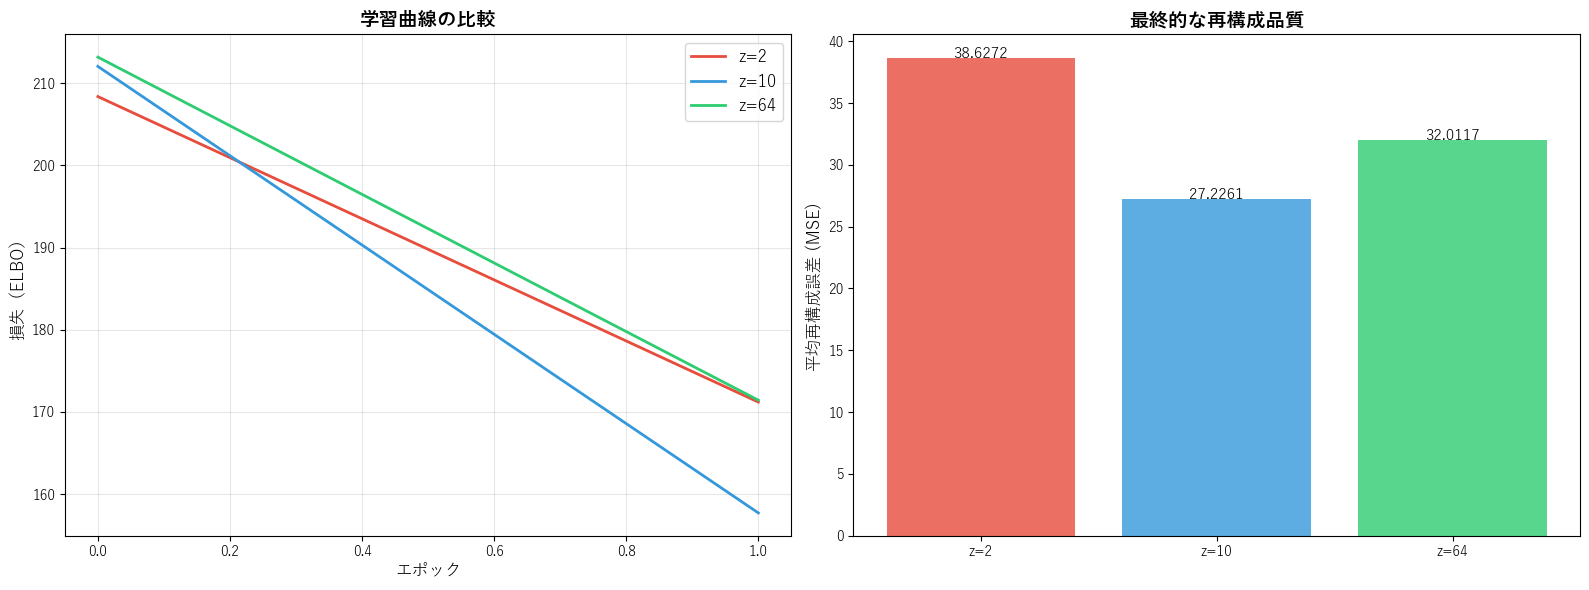

💡 潜在次元のトレードオフ:
   z=2:  再構成誤差 = 38.6272 (高い) → 可視化は容易
   z=10: 再構成誤差 = 27.2261 (中)  → バランスが良い
   z=64: 再構成誤差 = 32.0117 (低い) → 高品質だが冗長


In [13]:
# ============================================================
# 潜在次元数と再構成誤差の関係
# ============================================================

# 学習曲線の比較
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左: 学習曲線
colors_dim = {2: '#e74c3c', 10: '#3498db', 64: '#2ecc71'}
for dim in latent_dims:
    axes[0].plot(all_losses[dim], label=f'z={dim}',
                color=colors_dim[dim], linewidth=2)

axes[0].set_xlabel('エポック', fontsize=12)
axes[0].set_ylabel('損失（ELBO）', fontsize=12)
axes[0].set_title('学習曲線の比較', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

# 右: 最終的な再構成誤差
final_recon_errors = []
for dim in latent_dims:
    models[dim].eval()
    recon_error = 0
    with torch.no_grad():
        for batch_x, _ in test_loader:
            batch_x = batch_x.view(-1, 784).to(device)
            x_recon, _, _ = models[dim](batch_x)
            recon_error += nn.functional.mse_loss(x_recon, batch_x, reduction='sum').item()
    final_recon_errors.append(recon_error / len(test_dataset))

axes[1].bar([f'z={d}' for d in latent_dims], final_recon_errors,
           color=[colors_dim[d] for d in latent_dims], alpha=0.8)
axes[1].set_ylabel('平均再構成誤差 (MSE)', fontsize=12)
axes[1].set_title('最終的な再構成品質', fontsize=14, fontweight='bold')

for i, (dim, err) in enumerate(zip(latent_dims, final_recon_errors)):
    axes[1].text(i, err + 0.001, f'{err:.4f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('fig_301_08_dimension_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 潜在次元のトレードオフ:")
print(f"   z=2:  再構成誤差 = {final_recon_errors[0]:.4f} (高い) → 可視化は容易")
print(f"   z=10: 再構成誤差 = {final_recon_errors[1]:.4f} (中)  → バランスが良い")
print(f"   z=64: 再構成誤差 = {final_recon_errors[2]:.4f} (低い) → 高品質だが冗長")

---

## まとめ

### 🎯 このノートブックで学んだこと

**潜在空間の可視化テクニック**
- ✓ PCAで寄与率を分析し、有効次元数を把握できる
- ✓ t-SNEで高次元の潜在空間を2Dに射影してクラスタ構造を観察できる

**クラスタ構造の分析**
- ✓ 形が似た数字（3と8、4と9など）は潜在空間で近くに配置される
- ✓ 距離行列でクラスタ間の関係を定量化できる

**潜在次元数の影響**
- ✓ 次元が少ない → 可視化しやすいが情報損失が大きい
- ✓ 次元が多い → 高品質な再構成だがKL正則化で一部の次元が潰れる
- ✓ タスクに応じた適切な次元選択が重要

### 📊 チートシート

| 分析手法 | 目的 | 適用場面 |
|---------|------|---------|
| PCA寄与率 | 有効次元数の把握 | 潜在次元が冗長か判断 |
| t-SNE | クラスタ可視化 | 潜在表現の質の評価 |
| 距離行列 | クラスタ間関係の定量化 | 類似性の分析 |
| グリッドデコード | 空間の全体像 | 2D潜在空間のみ |
| 密度マップ | データ集中度の把握 | 生成品質の予測 |

### ⚠️ よくある間違い

❌ 「t-SNEの距離はデータの真の距離を反映している」
✅ t-SNEはクラスタの**分離**は保存するが、クラスタ**間**の距離には意味がない。距離の比較にはPCAや元の潜在空間での距離を使う

❌ 「潜在次元は多いほど良い」
✅ VAEのKL正則化により、使われない次元は潰される。むやみに大きくしても品質は頭打ちになる

### ✅ 学習チェックリスト

- [ ] PCAの寄与率から「有効次元数」を読み取れるか？
- [ ] t-SNEのperplexityパラメータの意味を説明できるか？
- [ ] 潜在空間の密度と生成品質の関係を理解しているか？
- [ ] 潜在次元の選び方のトレードオフを説明できるか？

---

**次のステップ**: ノートブック302「潜在ベクトル演算」で、z_smile - z_neutral + z_other = ? のようなベクトル演算を学び、属性ベクトルを発見します！

---

## 🎓 自己評価クイズ

### Q1: t-SNEとPCAの最大の違いは何か？学習済みモデルの潜在空間を分析するとき、どちらを先に使うべきか？

<details>
<summary>💡 答えを見る</summary>

**答え**: PCAは線形変換で全体の分散を保存し、t-SNEは非線形変換で局所的な近傍関係を保存する

先にPCAを使うべき。PCAは高速で、寄与率から有効次元数を把握できる。t-SNEは計算コストが高いが、クラスタの分離を可視化するのに優れている。

</details>

---

### Q2: 潜在次元=64のVAEで、PCAの寄与率分析をしたら最初の15次元で累積90%に達した。これは何を意味するか？

<details>
<summary>💡 答えを見る</summary>

**答え**: 64次元のうち、実質的に使われているのは約15次元ということ

残りの49次元はKL正則化によってN(0,1)に潰されており、ほとんど情報を持っていない。潜在次元を15-20に減らしても、再構成品質はほぼ変わらない可能性が高い。

</details>

---

### Q3: 数字3と8が潜在空間で近いのはなぜか？

<details>
<summary>💡 答えを見る</summary>

**答え**: 3と8は形が似ているため（3に横棒を足すと8になる）

VAEのエンコーダはピクセルパターンの類似性を学習するので、形状が似た数字は潜在空間で近い位置にエンコードされる。これにより、3→8の補間はスムーズで自然な変化になる。

</details>

---

### Q4: 潜在空間の「密度が低い領域」からデコードすると画像の品質が下がるのはなぜか？

<details>
<summary>💡 答えを見る</summary>

**答え**: デコーダはその領域の近くのデータをほとんど見たことがないため、適切な復元方法を学習できていない

VAEの学習は、実際のデータが集中する領域で行われる。データが少ない領域では、デコーダの出力は不確実になり、ぼやけたり不自然な画像が生成される。

</details>